# Handling Outliers in Exploratory Data Analysis (EDA)

## Objective

This notebook demonstrates different techniques used to identify, analyze, and handle outliers in a dataset.

Topics covered:

- Distribution analysis using KDE plots
- Skewness detection
- Outlier detection using Z-Score (3-Sigma Rule)
- Log Transformation
- Box Plot visualization
- Statistical summaries using describe()
- Percentiles and Quartiles

Outlier treatment is an important preprocessing step because extreme values can negatively impact statistical analysis and machine learning models.

In [27]:
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
df=pd.read_csv('raw_sales.csv')
df.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


## Visualizing Data Distribution

Kernel Density Estimation (KDE) plots help us understand the distribution of numerical variables.

In this example, we visualize the distribution of house prices.

A highly skewed distribution may indicate the presence of outliers.

## Measuring Skewness

Skewness measures the asymmetry of a distribution.

Interpretation:

- Skewness ≈ 0 → Normally distributed
- Skewness > 0 → Right skewed
- Skewness < 0 → Left skewed

Large skewness values often suggest the presence of extreme observations.

<Axes: xlabel='price', ylabel='Density'>

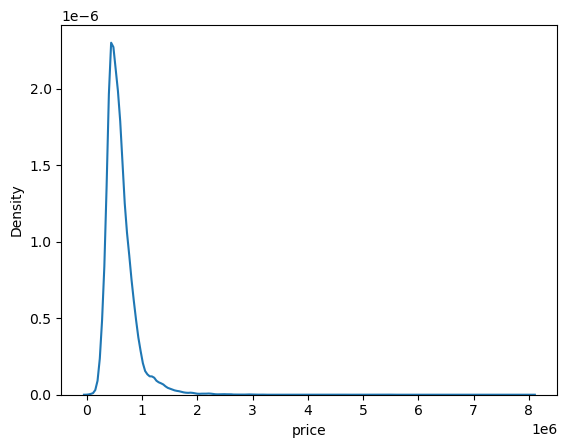

In [28]:
sns.kdeplot(df.price)

In [ ]:
#Price is right skewed

In [32]:
df['price'].skew()

np.float64(4.312009366902366)

## Outlier Detection Using Z-Score (3-Sigma Rule)

The Z-Score method identifies observations that are significantly different from the mean.

Formula:

Z = (X - Mean) / Standard Deviation

Using the 3-Sigma Rule:

- Values beyond 3 standard deviations from the mean are considered potential outliers.

This method works best when the data is approximately normally distributed.

In [22]:
def find_anomalies(data):
    anomalies=[]
    mean=data.mean()
    stddev=data.std()
    
    cutoff=stddev*3
    lower_limit=mean-cutoff
    upper_limit=mean+cutoff

    for val in data:
        if val>upper_limit or val<lower_limit:
            anomalies.append(val)
    return anomalies

## Number of Detected Outliers

After applying the Z-Score method, we calculate how many observations fall outside the acceptable range.

These observations may require further investigation or treatment.

In [37]:
outliers=find_anomalies(df['price'])
len(outliers)

461

In [26]:
len(df)

29580

## Handling Outliers Using Log Transformation

Log Transformation reduces the impact of large values by compressing the scale of the data.

Benefits:

- Reduces skewness
- Makes data closer to a normal distribution
- Improves model performance
- Reduces influence of extreme values

This technique is commonly used for financial and sales datasets.

In [31]:
df['price_transformed']=np.log(df['price'])

In [33]:
df['price_transformed'].skew()

np.float64(0.4731646269984763)

## Distribution After Transformation

After applying the logarithmic transformation, we visualize the distribution again.

A successful transformation should:

- Reduce skewness
- Produce a more symmetric distribution
- Reduce the effect of extreme observations

<Axes: xlabel='price_transformed', ylabel='Density'>

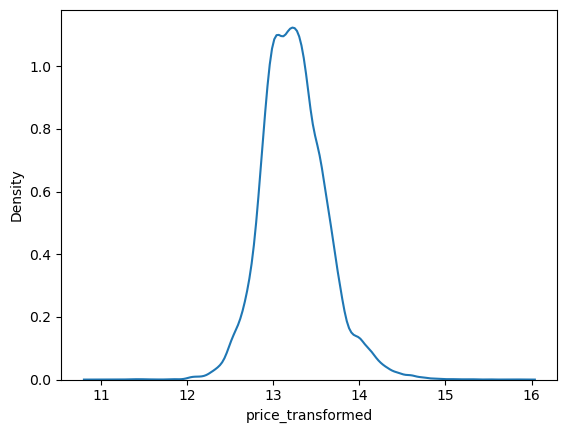

In [34]:
sns.kdeplot(df['price_transformed'])

## Re-evaluating Outliers

After transforming the data, we apply the same outlier detection method again.

The goal is to verify whether the transformation reduced the number of extreme observations.

In [39]:
transformed_outliers=find_anomalies(df['price_transformed'])
len(transformed_outliers)

266

## Outlier Detection Using Box Plots

Box plots provide a visual method for detecting outliers.

Components:

- Minimum
- First Quartile (Q1)
- Median (Q2)
- Third Quartile (Q3)
- Maximum

Points outside the whiskers are typically considered potential outliers.

Box plots are among the most commonly used techniques during EDA.

<Axes: >

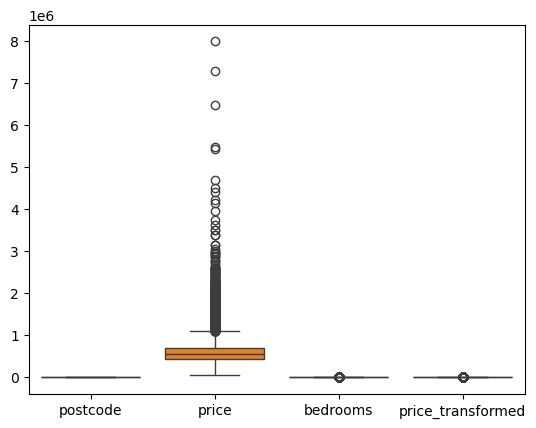

In [41]:
sns.boxplot(df)

<Axes: ylabel='price'>

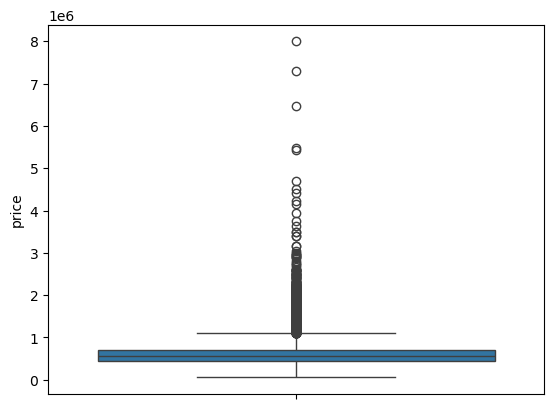

In [42]:
sns.boxplot(df['price'])

<Axes: ylabel='price_transformed'>

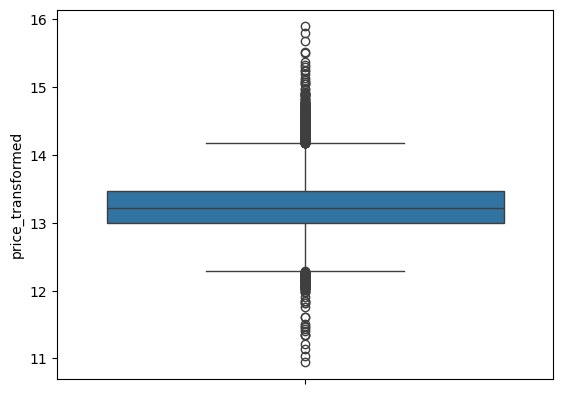

In [43]:
sns.boxplot(df['price_transformed'])

In [44]:
df.head()

,datesold,postcode,price,propertyType,bedrooms,price_transformed
0,2007-02-07 00:00:00,2607,525000,house,4,13.171154
1,2007-02-27 00:00:00,2906,290000,house,3,12.577636
2,2007-03-07 00:00:00,2905,328000,house,3,12.700769
3,2007-03-09 00:00:00,2905,380000,house,4,12.847927
4,2007-03-21 00:00:00,2906,310000,house,3,12.644328


## Statistical Summary

The describe() function provides key descriptive statistics:

- Count
- Mean
- Standard Deviation
- Minimum
- 25th Percentile (Q1)
- Median (Q2)
- 75th Percentile (Q3)
- Maximum

These metrics help us understand the distribution and spread of the data.

In [57]:
df.describe()

,postcode,price,bedrooms,price_transformed
count,29580.000000,2.958000e+04,29580.000000,29580.000000
mean,2730.249730,6.097363e+05,3.250169,13.244695
std,146.717292,2.817079e+05,0.951275,0.375214
min,2600.000000,5.650000e+04,0.000000,10.941996
25%,2607.000000,4.400000e+05,3.000000,12.994530
50%,2615.000000,5.500000e+05,3.000000,13.217674
75%,2905.000000,7.050000e+05,4.000000,13.465953
max,2914.000000,8.000000e+06,5.000000,15.894952


## Understanding Percentiles

Percentiles divide data into 100 equal parts.

Commonly used percentiles:

- 25th Percentile (Q1)
- 50th Percentile (Median)
- 75th Percentile (Q3)

Percentiles are frequently used for:

- Outlier detection
- Feature engineering
- Risk analysis
- Credit scoring models

### Percentile Example

To better understand how percentiles work, we generate a sample list of random numbers.

We then calculate:

- Minimum
- Maximum
- Mean
- Sorted Values
- 25th Percentile
- 50th Percentile
- 75th Percentile

These values help illustrate how quartiles divide a dataset.

In [48]:
import random
lst=[random.randint(1, 100) for _ in range(25)]
lst

[35,
 48,
 28,
 77,
 83,
 58,
 56,
 33,
 87,
 33,
 23,
 90,
 4,
 34,
 68,
 52,
 61,
 57,
 6,
 25,
 23,
 54,
 18,
 43,
 99]

In [49]:
max(lst)

99

In [50]:
min(lst)

4

In [51]:
statistics.mean(lst)

47.8

In [52]:
sorted(lst)

[4,
 6,
 18,
 23,
 23,
 25,
 28,
 33,
 33,
 34,
 35,
 43,
 48,
 52,
 54,
 56,
 57,
 58,
 61,
 68,
 77,
 83,
 87,
 90,
 99]

In [53]:
np.percentile(lst,25)

np.float64(28.0)

In [54]:
np.percentile(lst,50)

np.float64(48.0)

In [55]:
np.percentile(lst,75)

np.float64(61.0)

# Conclusion

In this notebook we explored multiple approaches for detecting and handling outliers:

1. Distribution Analysis using KDE plots
2. Skewness Measurement
3. Z-Score (3-Sigma Rule)
4. Log Transformation
5. Box Plot Analysis
6. Statistical Summaries
7. Percentile-Based Analysis

Key Observation:

- House prices exhibited significant positive skewness.
- Log transformation reduced skewness substantially.
- The number of detected outliers decreased after transformation.
- Box plots provided a visual confirmation of extreme observations.

These techniques form an essential part of Exploratory Data Analysis and are commonly used before building machine learning models.